# Goal:
See the trend from year to year demonstrating how the U.S. Government budgets its money
## Tasks:
1) Identify any missing values
2) Assess how to melt the columns and understand what are the given variables
3) Melt and split() to visualize the cleaned data (Both with and without NaN values)
4) Create a aggregate table using pivot()

# 1. Identify Missing Values

In [1]:
import pandas as pd

df = pd.read_csv('fed_rd_year&gdp.csv')
df.head()

,department,1976_gdp1790000000000.0,1977_gdp2028000000000.0,1978_gdp2278000000000.0,1979_gdp2570000000000.0,1980_gdp2797000000000.0,1981_gdp3138000000000.0,1982_gdp3314000000000.0,1983_gdp3541000000000.0,1984_gdp3953000000000.0,...,2008_gdp14752000000000.0,2009_gdp14415000000000.0,2010_gdp14799000000000.0,2011_gdp15379000000000.0,2012_gdp16027000000000.0,2013_gdp16516000000000.0,2014_gdp17244000000000.0,2015_gdp17983000000000.0,2016_gdp18470000000000.0,2017_gdp19177000000000.0
0,DHS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1155000000,1258000000,1009000000,848000000,527000000,737000000,1092000000,960000000,602000000,735000000
1,DOC,8.190000e+08,8.370000e+08,8.710000e+08,9.520000e+08,9.450000e+08,8.290000e+08,6.930000e+08,7.000000e+08,7.550000e+08,...,1379000000,1594000000,1521000000,1357000000,1373000000,1397000000,1641000000,1596000000,1730000000,1824000000
2,DOD,3.569600e+10,3.796700e+10,3.702200e+10,3.717400e+10,3.700500e+10,4.173700e+10,4.689300e+10,5.100800e+10,5.813900e+10,...,94247000000,93527000000,94325000000,88220000000,81543000000,70583000000,70341000000,69522000000,75213000000,51862000000
3,DOE,1.088200e+10,1.374100e+10,1.566300e+10,1.561200e+10,1.522600e+10,1.479800e+10,1.216000e+10,1.112900e+10,1.173100e+10,...,11343000000,11823000000,12329000000,11902000000,11839000000,11528000000,12686000000,15033000000,15504000000,15032000000
4,DOT,1.142000e+09,1.095000e+09,1.156000e+09,1.004000e+09,1.048000e+09,9.780000e+08,7.020000e+08,8.000000e+08,1.018000e+09,...,1016000000,1062000000,1221000000,1064000000,1007000000,881000000,843000000,926000000,910000000,936000000


# Comments:
First thing I noticed with just quickly looking at the data from my dataset that there are lots of missing values for DHS (Department of Homeland Security). This makes sense since there wasn't a DHS until November 25, 2002 where President George W. Bush signed the Homeland Security Act of 2002 into law. This evidently was a response to the 9/11 attacks in September.   

In [2]:
# Melt the dataframe to identify missing values
df_melted = df.melt(id_vars=['department'], 
					 var_name='year_gdp', 
					 value_name='rd_budget')

# Extract year and GDP from the 'year_gdp' column
df_melted[['year', 'gdp']] = df_melted['year_gdp'].str.extract(r'(\d{4})_gdp(.+)')
df_melted['year'] = df_melted['year'].astype(int)
df_melted['gdp'] = df_melted['gdp'].astype(float)
df_melted['rd_budget'] = pd.to_numeric(df_melted['rd_budget'], errors='coerce')

# Find rows with NaN in rd_budget
nan_rows = df_melted[df_melted['rd_budget'].isnull()]
print(nan_rows[['department', 'year', 'rd_budget']])

    department  year  rd_budget
0          DHS  1976        NaN
14         DHS  1977        NaN
28         DHS  1978        NaN
42         DHS  1979        NaN
56         DHS  1980        NaN
70         DHS  1981        NaN
84         DHS  1982        NaN
98         DHS  1983        NaN
112        DHS  1984        NaN
126        DHS  1985        NaN
140        DHS  1986        NaN
154        DHS  1987        NaN
168        DHS  1988        NaN
182        DHS  1989        NaN
196        DHS  1990        NaN
210        DHS  1991        NaN
224        DHS  1992        NaN
238        DHS  1993        NaN
252        DHS  1994        NaN
266        DHS  1995        NaN
280        DHS  1996        NaN
294        DHS  1997        NaN
308        DHS  1998        NaN
322        DHS  1999        NaN
336        DHS  2000        NaN
350        DHS  2001        NaN


I am really just going to ignore the values for now with the data, since I am just tidying and not yet doing analysis. 

# 2. Assessing how to melt data

First thing I noticed is that the original data is set such that I need to separate it by year and make a new column where it shows GDP. So I had to look up and learn how to deal with that issue within the string of the column to easily make two new columns with rd_budget and gdp

In [3]:
import pandas as pd

df = pd.read_csv('fed_rd_year&gdp.csv')
print("\nOriginal DataFrame:\n")
print(df.head())

# Extract year from column name and separate GDP value. Columns are named like: '1976_gdp1790000000000.0. 
# So, just need to separate year and the RD budget value and make it tidy. 

# Melt the dataframe
df_melted = df.melt(id_vars=['department'], 
                     var_name='year_gdp', 
                     value_name='rd_budget')

# Extract year and GDP from the 'year_gdp' column
# I had to look up how to deal with this problem given that the column names are not in a standard format. 
# The regex pattern captures the year (4 digits) and the GDP value that follows '_gdp'.
df_melted[['year', 'gdp']] = df_melted['year_gdp'].str.extract(r'(\d{4})_gdp(.+)')
df_melted['year'] = df_melted['year'].astype(int)
df_melted['gdp'] = df_melted['gdp'].astype(float)
df_melted['rd_budget'] = pd.to_numeric(df_melted['rd_budget'], errors='coerce')

# Keep only the columns you need
df_tidy = df_melted[['department', 'year', 'rd_budget', 'gdp']].dropna()
print("\nTidy DataFrame:\n")
print(df_tidy.head())
print(df_tidy.info())


Original DataFrame:

  department  1976_gdp1790000000000.0  1977_gdp2028000000000.0  \
0        DHS                      NaN                      NaN   
1        DOC             8.190000e+08             8.370000e+08   
2        DOD             3.569600e+10             3.796700e+10   
3        DOE             1.088200e+10             1.374100e+10   
4        DOT             1.142000e+09             1.095000e+09   

   1978_gdp2278000000000.0  1979_gdp2570000000000.0  1980_gdp2797000000000.0  \
0                      NaN                      NaN                      NaN   
1             8.710000e+08             9.520000e+08             9.450000e+08   
2             3.702200e+10             3.717400e+10             3.700500e+10   
3             1.566300e+10             1.561200e+10             1.522600e+10   
4             1.156000e+09             1.004000e+09             1.048000e+09   

   1981_gdp3138000000000.0  1982_gdp3314000000000.0  1983_gdp3541000000000.0  \
0                   

# 3. Visualization

In [4]:
import pandas as pd
import re

df = pd.read_csv('fed_rd_year&gdp.csv')

#Extract year from column name and separate GDP value. Columns are named like: '1976_gdp1790000000000.0. 
#So, just need to separate year and the RD budget value and make it tidy. 

#Melt the dataframe
df_melted = df.melt(id_vars=['department'], 
                     var_name='year_gdp', 
                     value_name='rd_budget')

#Extract year and GDP from the 'year_gdp' column
#I had to look up how to deal with this problem given that the column names are not in a standard format. 
#The regex pattern captures the year (4 digits) and the GDP value that follows '_gdp'.

df_melted[['year', 'gdp']] = df_melted['year_gdp'].str.extract(r'(\d{4})_gdp(.+)')
df_melted['year'] = df_melted['year'].astype(int)
df_melted['gdp'] = df_melted['gdp'].astype(float)
df_melted['rd_budget'] = pd.to_numeric(df_melted['rd_budget'], errors='coerce') #This, what I noticed, helps with any non-numeric values


# Keep only the columns you need
df_tidy = df_melted[['department', 'year', 'rd_budget', 'gdp']].dropna()

print(df_tidy.head())
print(df_tidy.info())


  department  year     rd_budget           gdp
1        DOC  1976  8.190000e+08  1.790000e+12
2        DOD  1976  3.569600e+10  1.790000e+12
3        DOE  1976  1.088200e+10  1.790000e+12
4        DOT  1976  1.142000e+09  1.790000e+12
5        EPA  1976  9.680000e+08  1.790000e+12
<class 'pandas.core.frame.DataFrame'>
Index: 562 entries, 1 to 587
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   department  562 non-null    object 
 1   year        562 non-null    int64  
 2   rd_budget   562 non-null    float64
 3   gdp         562 non-null    float64
dtypes: float64(2), int64(1), object(1)
memory usage: 22.0+ KB
None


In [5]:
# Another visualization of the data, removing NaN values and using str.split()

import pandas as pd

df = pd.read_csv('fed_rd_year&gdp.csv')

# Melt the dataframe
df_melted_alt = df.melt(id_vars=['department'], 
                        var_name='year_gdp', 
                        value_name='rd_budget')

# Extract year: split on '_' and take the first part
df_melted_alt['year'] = df_melted_alt['year_gdp'].str.split('_').str[0].astype(int)

# Extract GDP: split on '_gdp' and take the second part
df_melted_alt['gdp'] = df_melted_alt['year_gdp'].str.split('_gdp').str[1].astype(float)

# Convert rd_budget to numeric, coercing errors to NaN
df_melted_alt['rd_budget'] = pd.to_numeric(df_melted_alt['rd_budget'], errors='coerce')

# Keep only the columns you need and drop NaN
df_tidy_alt = df_melted_alt[['department', 'year', 'rd_budget', 'gdp']].dropna()

print("Another Tidy DataFrame:\n")
print(df_tidy_alt.head(10))
print(df_tidy_alt.info())

Another Tidy DataFrame:

   department  year     rd_budget           gdp
1         DOC  1976  8.190000e+08  1.790000e+12
2         DOD  1976  3.569600e+10  1.790000e+12
3         DOE  1976  1.088200e+10  1.790000e+12
4         DOT  1976  1.142000e+09  1.790000e+12
5         EPA  1976  9.680000e+08  1.790000e+12
6         HHS  1976  9.226000e+09  1.790000e+12
7    Interior  1976  1.152000e+09  1.790000e+12
8        NASA  1976  1.251300e+10  1.790000e+12
9         NIH  1976  8.025000e+09  1.790000e+12
10        NSF  1976  2.372000e+09  1.790000e+12
<class 'pandas.core.frame.DataFrame'>
Index: 562 entries, 1 to 587
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   department  562 non-null    object 
 1   year        562 non-null    int64  
 2   rd_budget   562 non-null    float64
 3   gdp         562 non-null    float64
dtypes: float64(2), int64(1), object(1)
memory usage: 22.0+ KB
None


# Bar Graph

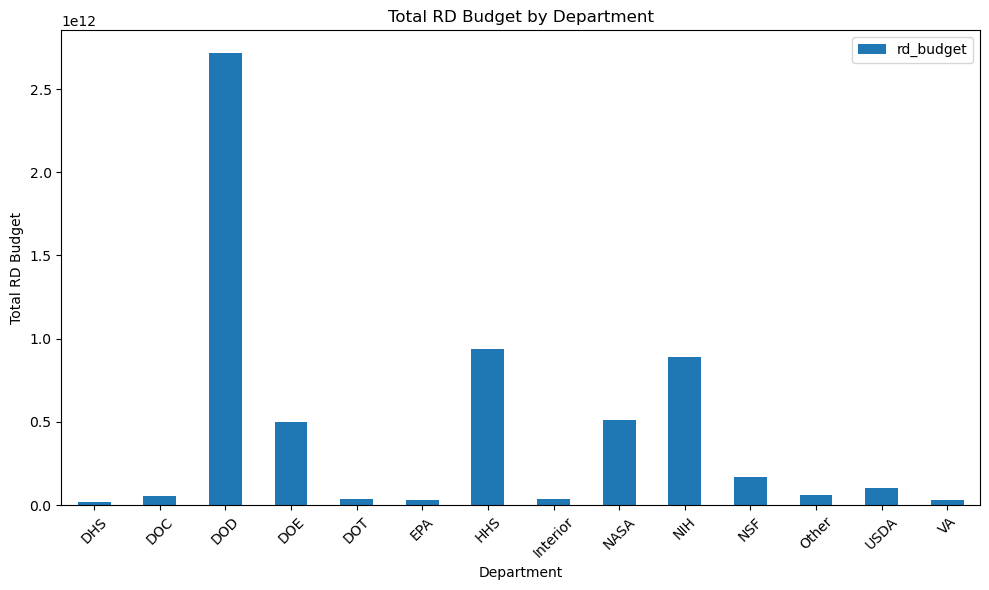

In [6]:
import matplotlib.pyplot as plt

# Create the pivot table
pivot_table = df_tidy.pivot_table(index='department', values='rd_budget', aggfunc='sum')

# Create a bar graph from the pivot table
pivot_table.plot(kind='bar', figsize=(10, 6))
plt.title('Total RD Budget by Department')
plt.xlabel('Department')
plt.ylabel('Total RD Budget')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

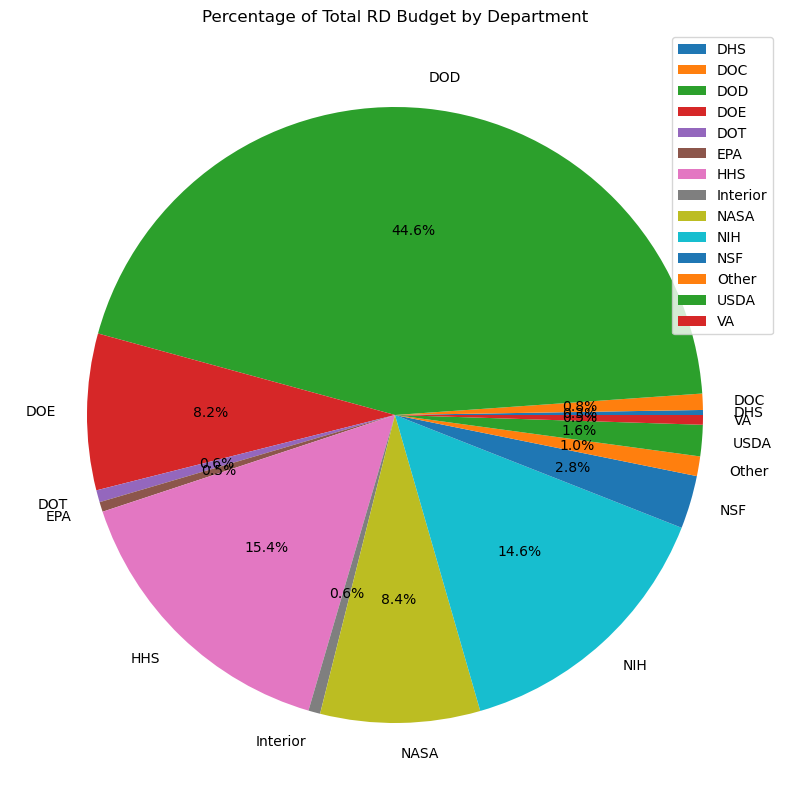

In [7]:
pivot_table.plot(kind='pie', y='rd_budget', autopct='%1.1f%%', figsize=(10, 10))
plt.title('Percentage of Total RD Budget by Department')
plt.ylabel('')
plt.show()

# 4. Pivot Table

Next part to the task is to make a Pivot-Table to run an aggregation on the tidy data.

In [8]:
pivot_table = df_tidy.pivot_table(index='department', values='rd_budget', aggfunc='sum')
print("\nPivot Table:\n")
print(pivot_table)


Pivot Table:

               rd_budget
department              
DHS         1.591800e+10
DOC         5.172300e+10
DOD         2.716778e+12
DOE         4.991020e+11
DOT         3.854700e+10
EPA         3.151800e+10
HHS         9.364640e+11
Interior    3.782400e+10
NASA        5.098910e+11
NIH         8.869380e+11
NSF         1.696300e+11
Other       6.278000e+10
USDA        9.999400e+10
VA          3.082300e+10
